<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Polynomial Regression using GridSearchCV

The following dataset represents the relationship between the number of hours spent practicing a skill and the performance score obtained in an assessment.

Build a **Polynomial Regression** model and use **GridSearchCV** to determine the optimal polynomial degree (1–5).

## Dataset

| Hours of Practice (X) | Performance Score (Y) |
|:---------------------:|:---------------------:|
| 1 | 3.2 |
| 2 | 5.1 |
| 3 | 8.8 |
| 4 | 15.6 |
| 5 | 25.4 |
| 6 | 38.2 |
| 7 | 54.1 |
| 8 | 73.5 |
| 9 | 96.8 |
| 10 | 123.2 |
| 11 | 154.6 |
| 12 | 190.8 |

## Tasks

- Create the dataset using **NumPy**.
- Split the data into **training and testing sets (80:20)**.
- Build a **Pipeline** consisting of:
  - PolynomialFeatures
  - LinearRegression
- Use **GridSearchCV** to search for the best polynomial degree from **1 to 5**.
- Use **5-fold cross-validation**.

## Display

- Best polynomial degree
- Best cross-validation score
- Predict the test set values

## Compute

- Mean Squared Error (MSE)
- R² Score

## Plot

- Original data
- Best fitted polynomial curve

Best Degree: 3
Best CV Score: 0.999977112661453
Mean Sqaured Error: 0.35897200298572524
R2 Score: 0.9999156637053938


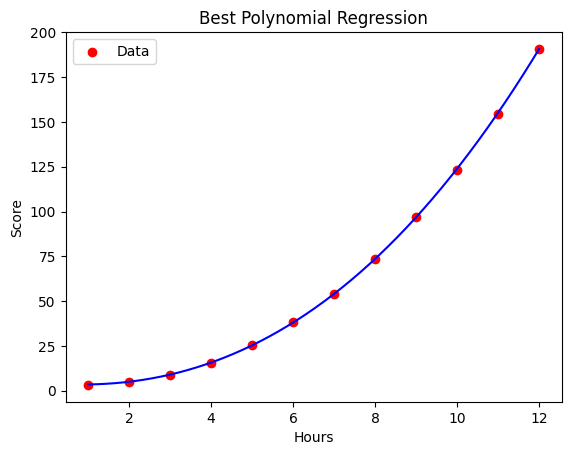

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=np.array([1,2,3,4,5,6, 7, 8, 9, 10, 11, 12]).reshape(-1,1)
Y=np.array([3.2, 5.1, 8.8, 15.6, 25.4, 38.2, 54.1, 73.5, 96.8, 123.2, 154.6, 190.8])
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
pipeline = Pipeline([
    ("poly", PolynomialFeatures()),
    ("linear", LinearRegression())
])
param_grid={
    "poly__degree":[1,2,3,4,5]
}
gridsearch=GridSearchCV(pipeline, param_grid,cv=3, scoring="r2")
gridsearch.fit(X_train, Y_train)
print("Best Degree:", gridsearch.best_params_["poly__degree"])
print("Best CV Score:", gridsearch.best_score_)
best_model=gridsearch.best_estimator_
Y_pred=best_model.predict(X_test)
print("Mean Sqaured Error:", mean_squared_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))
X_plot=np.linspace(1,12,200).reshape(-1,1)
y_plot=gridsearch.predict(X_plot)

plt.scatter(X,Y,color="red",label="Data")
plt.plot(X_plot,y_plot,color="blue")
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Best Polynomial Regression")
plt.legend()
plt.show()

Implement Polynomial Regression on Auto MPG dataset using GridSearch and Cross Validation to select the optimal polynomial degree for regression.

## Tasks

1. Load the Auto MPG dataset.

2. Preprocess the dataset.

3. Implement Polynomial Regression.

4. Use GridSearchCV to find the optimal polynomial degree.

5. Apply Cross Validation to evaluate the model.

6. Select the best polynomial model based on performance.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df=sns.load_dataset("mpg")
df = df.replace("?",np.nan)
df = df.dropna()
df["displacement"] = df["displacement"].astype(float)

X = df[["displacement"]]
y = df["mpg"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2, random_state=42)

pipe = Pipeline([
    ("poly",PolynomialFeatures()),
    ("lr",LinearRegression())
])

param_grid={
    "poly__degree":[1,2,3,4,5]
}

grid=GridSearchCV(pipe,param_grid,cv=3)

grid.fit(X_train,y_train)

print("Best Degree:",grid.best_params_)
print("Best Score:",grid.best_score_)

pred=grid.predict(X_test)

print("MSE:",mean_squared_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

Best Degree: {'poly__degree': 2}
Best Score: 0.7025688352025933
MSE: 20.649054718307305
R2: 0.5954385038809804


The following dataset represents the relationship between the study hours of students and their examination scores.

Fit Polynomial Regression models of different degrees (1 to 6).

Compare their training and testing errors to identify underfitting, overfitting, and the optimal model complexity.

## Dataset

| Hours Studied (X) | Exam Score (Y) |
|---|---|
| 1 | 5 |
| 2 | 8 |
| 3 | 15 |
| 4 | 24 |
| 5 | 36 |
| 6 | 50 |
| 7 | 67 |
| 8 | 85 |
| 9 | 108 |
| 10 | 130 |
| 11 | 158 |
| 12 | 190 |
| 13 | 225 |
| 14 | 265 |
| 15 | 310 |

The data approximately follows a quadratic relationship with a small amount of noise.

## Tasks

1. Create the dataset using NumPy.

2. Split the data into training and testing sets (70:30).

3. Train Polynomial Regression models with degrees 1-6

4. For each model:

- Calculate the training MSE.
- Calculate the testing MSE.

5. Display the results in a table.

6. Plot:

- Training Error vs Degree
- Testing Error vs Degree

7. Identify:

- Underfitting model
- Best model
- Overfitting model

   Degree  Training MSE  Testing MSE
0       1    528.394709   795.302159
1       2      5.287385     7.717869
2       3      0.738032     4.618582
3       4      0.192887     0.484861
4       5      0.191489     0.390089
5       6      0.157125     2.859992


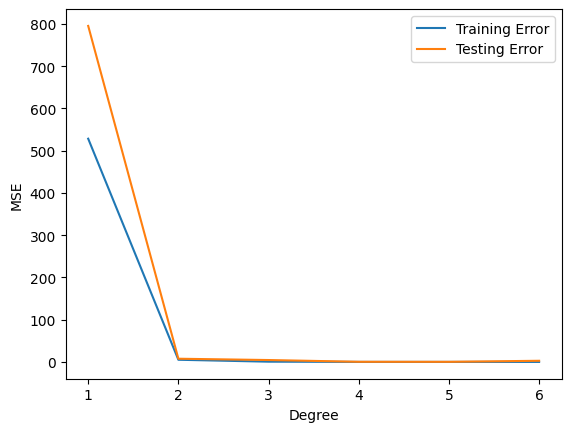

Underfitting Degree: 1
Best Degree: 5
Possible Overfitting Degree: 6


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X=np.arange(1,16).reshape(-1,1)

y=np.array([5,8,15,24,36,50,67,85,
            108,130,158,190,225,265,310])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42)

train_error=[]
test_error=[]

for degree in range(1,7):

    model=Pipeline([
        ("poly",PolynomialFeatures(degree)),
        ("lr",LinearRegression())
    ])

    model.fit(X_train,y_train)

    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)

    train_error.append(mean_squared_error(y_train,train_pred))
    test_error.append(mean_squared_error(y_test,test_pred))

results=pd.DataFrame({
    "Degree":range(1,7),
    "Training MSE":train_error,
    "Testing MSE":test_error
})

print(results)

plt.plot(range(1,7),train_error,label="Training Error")
plt.plot(range(1,7),test_error,label="Testing Error")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

best=np.argmin(test_error)+1

print("Underfitting Degree: 1")
print("Best Degree:",best)
print("Possible Overfitting Degree: 6")

Use California Housing dataset from sklearn and understand the bias variance trade-off.

## Tasks

1. Load the California Housing dataset.

2. Select one feature.

    Example:

    RM: Average number of rooms

3. Split into:

- Training set
- Validation set

4. Apply Polynomial Regression for different degrees.

5. Compute:

- Training MSE
- Validation MSE

6. Plot error curves.

7. Analyze the results.

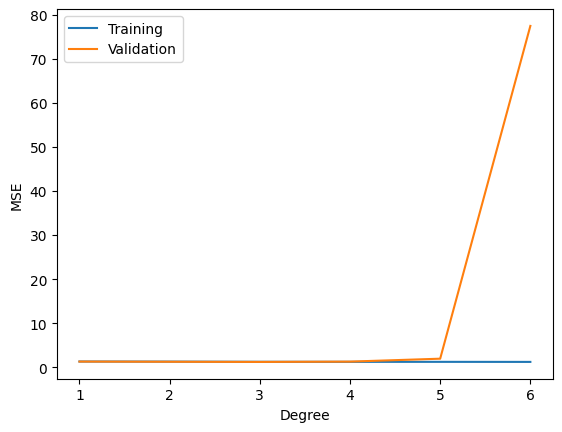

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

housing=fetch_california_housing(as_frame=True)

X=housing.data[["AveRooms"]]
y=housing.target

X_train,X_val,y_train,y_val=train_test_split(
    X,y,test_size=0.2,random_state=42)

train_error=[]
val_error=[]

for d in range(1,7):

    model=Pipeline([
        ("poly",PolynomialFeatures(d)),
        ("lr",LinearRegression())
    ])

    model.fit(X_train,y_train)

    train_pred=model.predict(X_train)
    val_pred=model.predict(X_val)

    train_error.append(mean_squared_error(y_train,train_pred))
    val_error.append(mean_squared_error(y_val,val_pred))

plt.plot(range(1,7),train_error,label="Training")
plt.plot(range(1,7),val_error,label="Validation")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

The following dataset contains the advertising expenditure on **TV, Radio, and Newspaper** along with the corresponding **product sales**.

Develop the following regression models to predict sales:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression

Compare the models based on:

- Regression coefficients
- Mean Squared Error (MSE)
- R² Score


## Dataset

| TV | Radio | Newspaper | Sales |
|---|---|---|---|
| 50 | 30 | 10 | 11 |
| 60 | 25 | 12 | 13 |
| 70 | 35 | 15 | 16 |
| 80 | 40 | 18 | 18 |
| 90 | 45 | 20 | 20 |
| 100 | 50 | 22 | 23 |
| 110 | 55 | 24 | 25 |
| 120 | 60 | 26 | 28 |
| 130 | 65 | 28 | 30 |
| 140 | 70 | 30 | 33 |
| 150 | 75 | 32 | 35 |
| 160 | 80 | 35 | 38 |


## Tasks

### 1. Dataset Creation

Create the given dataset using **Pandas**.

- Store TV, Radio, and Newspaper expenditure as input features.
- Store Sales as the target variable.


### 2. Data Splitting

Split the dataset into training and testing sets.

Use:

```

Training data : 80%
Testing data  : 20%

```

### 3. Build Regression Models

Train the following models:

### a) Linear Regression

Implement a standard Linear Regression model.


### b) Ridge Regression

Implement Ridge Regression using:

```

alpha = 1.0

```


### c) Lasso Regression

Implement Lasso Regression using:

```

alpha = 1.0

```


### 4. Prediction

Use the trained models to predict sales values for the test dataset.


### 5. Model Comparison

Compare the performance of all three models using:


### Regression Coefficients

Display the coefficients obtained by each model.


### Mean Squared Error (MSE)

Calculate and compare the Mean Squared Error of:

- Linear Regression
- Ridge Regression
- Lasso Regression


### R² Score

Calculate and compare the R² Score of:

- Linear Regression
- Ridge Regression
- Lasso Regression


## Expected Analysis

Determine which regression model performs best based on:

- Lowest MSE
- Highest R² Score
- Effect of regularization on regression coefficients


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

df=pd.DataFrame({

"TV":[50,60,70,80,90,100,110,120,130,140,150,160],

"Radio":[30,25,35,40,45,50,55,60,65,70,75,80],

"Newspaper":[10,12,15,18,20,22,24,26,28,30,32,35],

"Sales":[11,13,16,18,20,23,25,28,30,33,35,38]

})

X=df[["TV","Radio","Newspaper"]]
y=df["Sales"]

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

models={
"Linear":LinearRegression(),
"Ridge":Ridge(alpha=1),
"Lasso":Lasso(alpha=1)
}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print("\n",name)

    print("Coefficients:",model.coef_)

    print("MSE:",mean_squared_error(y_test,pred))

    print("R2:",r2_score(y_test,pred))


 Linear
Coefficients: [ 0.2625  0.075  -0.25  ]
MSE: 0.072916666666664
R2: 0.9993832236842105

 Ridge
Coefficients: [ 0.24465202  0.036646   -0.07871871]
MSE: 0.04258434872727018
R2: 0.9996397940427204

 Lasso
Coefficients: [0.24537709 0.         0.        ]
MSE: 0.08218593624834851
R2: 0.9993048182084256


Implement Ridge and Lasso Regression on the Diabetes dataset.

Compare the performance of these regularized models with standard Linear Regression.

## Tasks

1. Load and preprocess the dataset.

2. Implement:

- Ridge Regression
- Lasso Regression

3. Tune hyperparameters using Cross Validation.

4. Compare performance metrics:

- Mean Squared Error (MSE)
- R-squared Score

with standard Linear Regression.

In [ ]:
from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,r2_score

data=load_diabetes()

X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

linear=LinearRegression()

linear.fit(X_train,y_train)

pred=linear.predict(X_test)

print("Linear Regression")
print("MSE:",mean_squared_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

ridge=GridSearchCV(
Ridge(),
{"alpha":[0.01,0.1,1,10,100]},
cv=5)

ridge.fit(X_train,y_train)

pred=ridge.predict(X_test)

print("\nBest Ridge Alpha:",ridge.best_params_)

print("Ridge MSE:",mean_squared_error(y_test,pred))

print("Ridge R2:",r2_score(y_test,pred))

lasso=GridSearchCV(
Lasso(max_iter=10000),
{"alpha":[0.01,0.1,1,10]},
cv=5)

lasso.fit(X_train,y_train)

pred=lasso.predict(X_test)

print("\nBest Lasso Alpha:",lasso.best_params_)

print("Lasso MSE:",mean_squared_error(y_test,pred))

print("Lasso R2:",r2_score(y_test,pred))

Linear Regression
MSE: 2900.193628493482
R2: 0.4526027629719195

Best Ridge Alpha: {'alpha': 0.1}
Ridge MSE: 2856.4868876706537
Ridge R2: 0.46085219464119265

Best Lasso Alpha: {'alpha': 0.1}
Lasso MSE: 2798.193485169719
Lasso R2: 0.4718547867276227
